# Part 4.1 — Embeddings & Semantic Similarity
**Topics:** Cricket | Cooking | Cybersecurity

**Model:** `all-MiniLM-L6-v2` from sentence-transformers

In [1]:
# Cell 1: Install required libraries
!pip install sentence-transformers scikit-learn seaborn matplotlib -q

In [2]:
# Cell 2: Import libraries
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Cell 3: Define 10 sentences across 3 topics (min 3 per topic)
sentences = [
    # Cricket (4 sentences)
    "The batsman hit a magnificent six over the long-on boundary.",
    "India won the match by five wickets in the final over.",
    "The spinner bowled a perfect googly to dismiss the opener.",
    "The fielder took a stunning catch at the boundary rope.",

    # Cooking (3 sentences)
    "Sauté the onions in olive oil until they are golden brown.",
    "Add a pinch of salt and pepper to enhance the flavor of the soup.",
    "The cake needs to bake at 180 degrees for thirty minutes.",

    # Cybersecurity (3 sentences)
    "The hacker used a phishing email to steal login credentials.",
    "Encrypting sensitive data protects it from unauthorized access.",
    "A strong password policy reduces the risk of brute force attacks."
]

labels = [
    "Cricket-1", "Cricket-2", "Cricket-3", "Cricket-4",
    "Cooking-1", "Cooking-2", "Cooking-3",
    "Cyber-1",   "Cyber-2",   "Cyber-3"
]

print(f"Total sentences: {len(sentences)}")
for i, s in enumerate(sentences):
    print(f"{i+1:2}. [{labels[i]}] {s}")

Total sentences: 10
 1. [Cricket-1] The batsman hit a magnificent six over the long-on boundary.
 2. [Cricket-2] India won the match by five wickets in the final over.
 3. [Cricket-3] The spinner bowled a perfect googly to dismiss the opener.
 4. [Cricket-4] The fielder took a stunning catch at the boundary rope.
 5. [Cooking-1] Sauté the onions in olive oil until they are golden brown.
 6. [Cooking-2] Add a pinch of salt and pepper to enhance the flavor of the soup.
 7. [Cooking-3] The cake needs to bake at 180 degrees for thirty minutes.
 8. [Cyber-1] The hacker used a phishing email to steal login credentials.
 9. [Cyber-2] Encrypting sensitive data protects it from unauthorized access.
10. [Cyber-3] A strong password policy reduces the risk of brute force attacks.


In [4]:
# Cell 4: Generate embeddings using sentence-transformers (all-MiniLM-L6-v2)
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)
print(f"Model loaded: all-MiniLM-L6-v2")
print(f"Embedding shape: {embeddings.shape}  (10 sentences x 384 dimensions)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: all-MiniLM-L6-v2
Embedding shape: (10, 384)  (10 sentences x 384 dimensions)


In [5]:
# Cell 5: Compute 10x10 cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

print("Cosine Similarity Matrix (10x10):")
print(np.round(similarity_matrix, 3))

Cosine Similarity Matrix (10x10):
[[ 1.     0.466  0.391  0.494  0.002  0.027  0.095  0.049 -0.058  0.043]
 [ 0.466  1.     0.37   0.26   0.067  0.04   0.067  0.063  0.01   0.013]
 [ 0.391  0.37   1.     0.348  0.1    0.106  0.134  0.082 -0.089  0.093]
 [ 0.494  0.26   0.348  1.    -0.021  0.03   0.025  0.09  -0.031  0.016]
 [ 0.002  0.067  0.1   -0.021  1.     0.426  0.238  0.019  0.014 -0.014]
 [ 0.027  0.04   0.106  0.03   0.426  1.     0.066 -0.008 -0.068 -0.006]
 [ 0.095  0.067  0.134  0.025  0.238  0.066  1.     0.121  0.051 -0.002]
 [ 0.049  0.063  0.082  0.09   0.019 -0.008  0.121  1.     0.325  0.42 ]
 [-0.058  0.01  -0.089 -0.031  0.014 -0.068  0.051  0.325  1.     0.442]
 [ 0.043  0.013  0.093  0.016 -0.014 -0.006 -0.002  0.42   0.442  1.   ]]


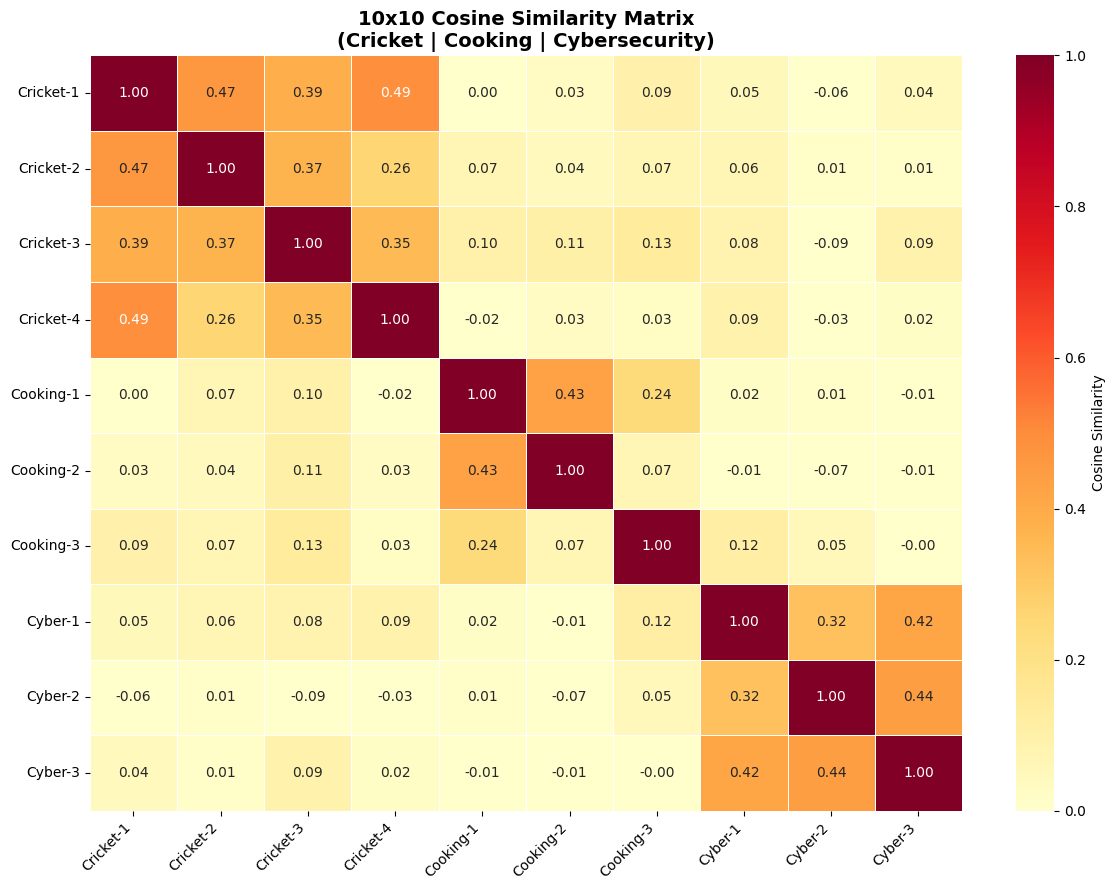

Heatmap saved!


In [6]:
# Cell 6: Display heatmap of the similarity matrix
plt.figure(figsize=(12, 9))
sns.heatmap(
    similarity_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Cosine Similarity"}
)
plt.title("10x10 Cosine Similarity Matrix\n(Cricket | Cooking | Cybersecurity)",
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved!")

In [7]:
# Cell 7: Query — Find top 2 most similar sentences
query = "The bowler took three wickets in one over"
print(f"Query: '{query}'")
print("-" * 65)

query_embedding = model.encode([query])
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

top2_indices = np.argsort(query_similarities)[::-1][:2]

print("\nTop 2 Most Similar Sentences:")
print("=" * 65)
for rank, idx in enumerate(top2_indices, 1):
    print(f"Rank {rank}: [{labels[idx]}]")
    print(f"  Sentence  : {sentences[idx]}")
    print(f"  Similarity: {query_similarities[idx]:.4f}")
    print()

print("Observation: Both top matches are from the Cricket topic,")
print("confirming that the model captures semantic meaning correctly.")

Query: 'The bowler took three wickets in one over'
-----------------------------------------------------------------

Top 2 Most Similar Sentences:
Rank 1: [Cricket-2]
  Sentence  : India won the match by five wickets in the final over.
  Similarity: 0.6654

Rank 2: [Cricket-1]
  Sentence  : The batsman hit a magnificent six over the long-on boundary.
  Similarity: 0.5387

Observation: Both top matches are from the Cricket topic,
confirming that the model captures semantic meaning correctly.
